# 05b - Choose k (silhouette diagnostic)

**Input:** `data/processed/player_features.csv`, `data/processed/player_sex.csv`
**What it does:** computes silhouette scores across k=2..6 for each sex, so the data (not an assumption) sets the number of playstyle groups. Interpretation: >0.50 strong, 0.25-0.50 weak-but-real, <0.25 essentially no structure.
**Output:** `output/silhouette_by_k.png`, printed table.

Result: women's peaks weakly (~0.22) at k=3; men's never clears noise, which is why men's clustering is dropped.

In [1]:
## --- path bootstrap: run from the repo root no matter where this is launched ---
## nbconvert and some editors set the working directory to the notebook's own
## folder. Walk up until we find the repo root (the folder containing data/),
## chdir there so relative data paths resolve, and put code/ on sys.path so the
## shared modules (utils.py, shot_translations.py) import cleanly.
import os, sys
_d = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_d, "data")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
if os.path.join(_d, "code") not in sys.path:
    sys.path.insert(0, os.path.join(_d, "code"))
print("working directory:", os.getcwd())

working directory: /Users/aakankshvaidya/Desktop/qss20_final_project


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
## CONFIG
PROC_DIR = "data/processed"
OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)
K_RANGE = range(2, 7)
LINKAGE_METHOD = "ward"
CLUSTER_FEATURES = [
    "pct_smash", "pct_attacking", "pct_defensive", "pct_net", "pct_neutral",
    "mean_depth_from_center", "mean_displacement_applied",
    "mean_rally_length_when_won", "pct_wins_by_winner", "landing_x_std",
]

In [4]:
features_full = pd.read_csv(os.path.join(PROC_DIR, "player_features.csv"), index_col="player_name")
player_sex = pd.read_csv(os.path.join(PROC_DIR, "player_sex.csv")).set_index("player_name")
features_full = features_full.join(player_sex)

## Compute silhouette scores per sex per k

In [5]:
results = {}
for sex in ["W", "M"]:
    sub = features_full[features_full["sex"] == sex][CLUSTER_FEATURES]
    X = StandardScaler().fit_transform(sub)
    Z = linkage(X, method=LINKAGE_METHOD)
    print(f"\n=== SEX={sex} (n={len(sub)} players) ===")
    scores = {}
    for k in K_RANGE:
        if k >= len(sub):
            continue
        labels = fcluster(Z, t=k, criterion="maxclust")
        if len(set(labels)) < 2:
            continue
        score = silhouette_score(X, labels)
        scores[k] = score
        sizes = pd.Series(labels).value_counts().sort_index().tolist()
        print(f"  k={k}: silhouette={score:.3f}   cluster sizes={sizes}")
    results[sex] = scores
    best_k = max(scores, key=scores.get)
    print(f"  --> best k by silhouette: {best_k} (score={scores[best_k]:.3f})")


=== SEX=W (n=13 players) ===
  k=2: silhouette=0.197   cluster sizes=[8, 5]
  k=3: silhouette=0.217   cluster sizes=[8, 2, 3]
  k=4: silhouette=0.208   cluster sizes=[7, 1, 2, 3]
  k=5: silhouette=0.209   cluster sizes=[3, 4, 1, 2, 3]
  k=6: silhouette=0.195   cluster sizes=[3, 4, 1, 2, 2, 1]
  --> best k by silhouette: 3 (score=0.217)

=== SEX=M (n=22 players) ===
  k=2: silhouette=0.235   cluster sizes=[3, 19]
  k=3: silhouette=0.146   cluster sizes=[3, 13, 6]
  k=4: silhouette=0.142   cluster sizes=[3, 13, 5, 1]
  k=5: silhouette=0.123   cluster sizes=[3, 4, 9, 5, 1]
  k=6: silhouette=0.140   cluster sizes=[3, 4, 9, 4, 1, 1]
  --> best k by silhouette: 2 (score=0.235)


## Plot

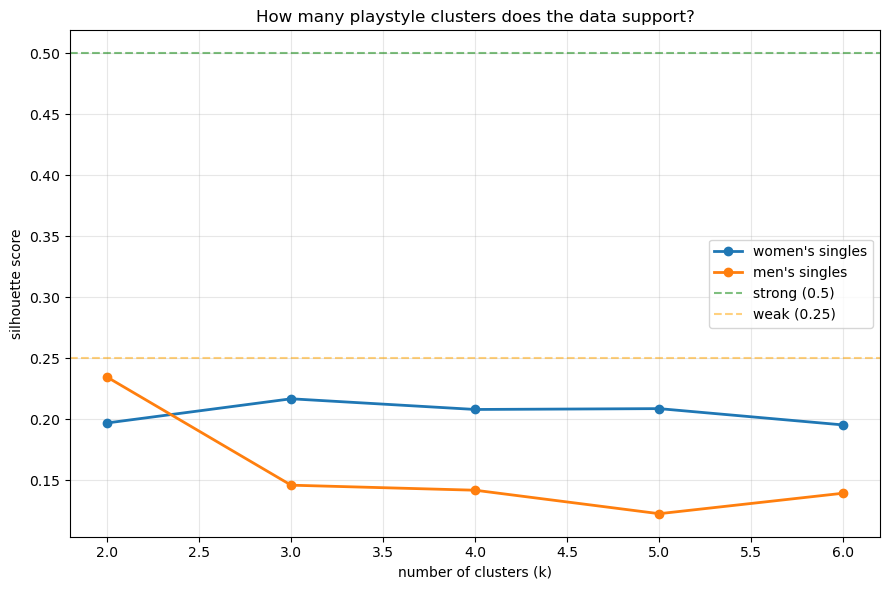

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
for sex, scores in results.items():
    label = "women's" if sex == "W" else "men's"
    ax.plot(list(scores.keys()), list(scores.values()), marker="o", linewidth=2, label=f"{label} singles")
ax.axhline(0.5, color="green", linestyle="--", alpha=0.5, label="strong (0.5)")
ax.axhline(0.25, color="orange", linestyle="--", alpha=0.5, label="weak (0.25)")
ax.set_xlabel("number of clusters (k)")
ax.set_ylabel("silhouette score")
ax.set_title("How many playstyle clusters does the data support?")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "silhouette_by_k.png"), dpi=150)
plt.show()